In [2]:
import networkx as nx

In [3]:
graph = nx.read_gexf("labeled_graph.gexf")

In [4]:
from collections import defaultdict

graphs = defaultdict(lambda:nx.Graph())

for a, b, data in graph.edges(data=True):
    graphs[data["subreddit"]].add_edge(a, b, weight = data["weight"])

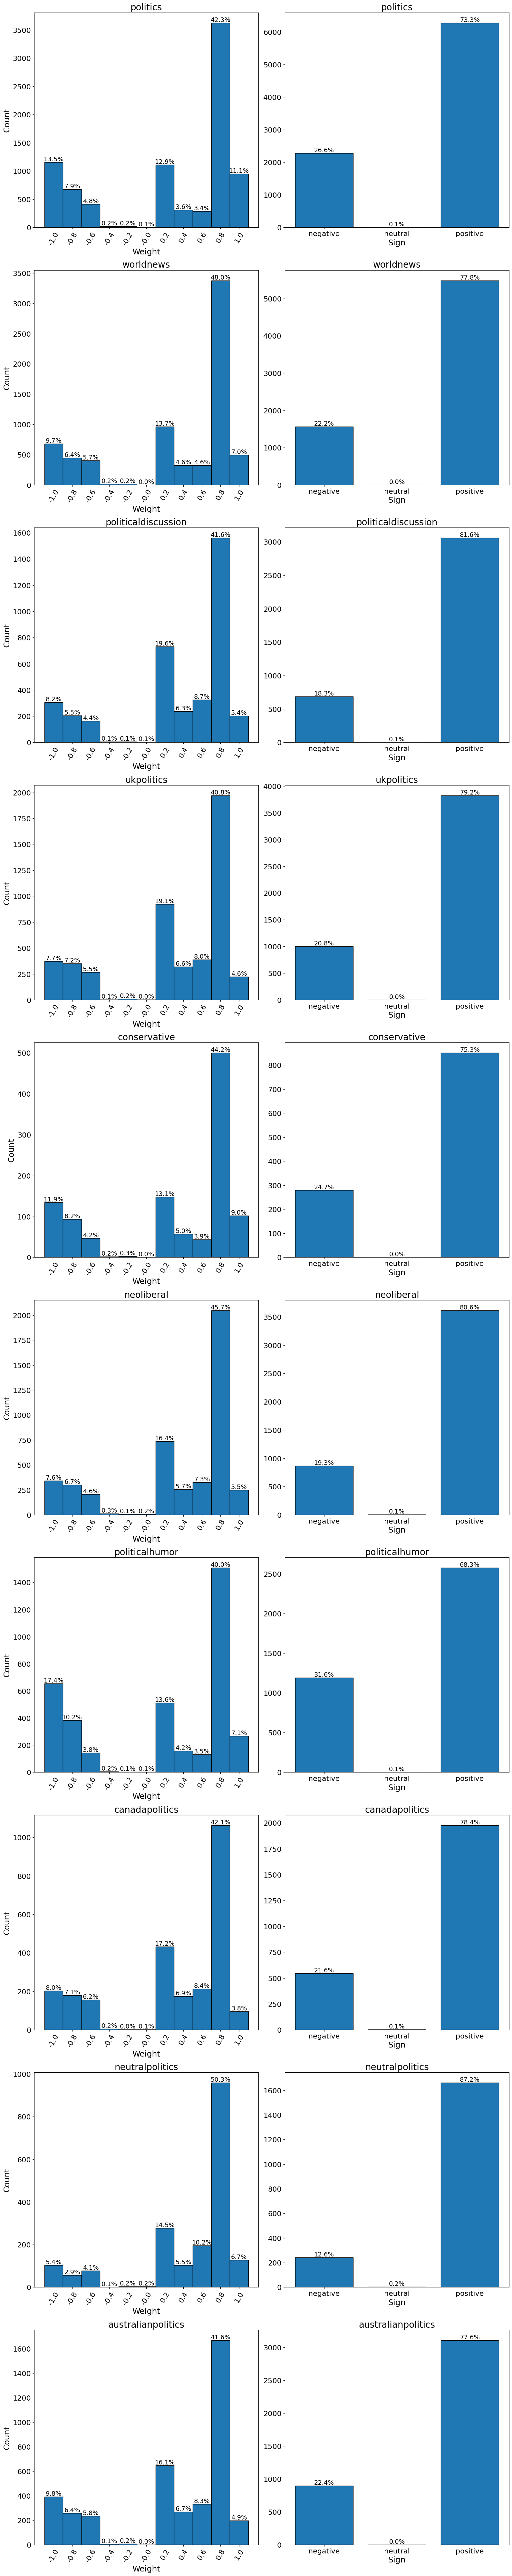

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(graphs), 2, figsize=(16, 8 * len(graphs)))

centers = np.arange(-1, 1.1, 0.2)
edges = centers - .1
edges = np.append(edges, edges[-1] + 0.2)  # add rightmost edge

for ind, subreddit in enumerate(graphs):
    axes[ind][0].set_title(subreddit, fontsize=20)
    axes[ind][1].set_title(subreddit, fontsize=20)
    w = np.array([data["weight"] for a, b, data in graphs[subreddit].edges(data=True)])
    
    # Histogram for weights
    counts, bins, patches = axes[ind][0].hist(w, bins=edges, edgecolor="black")
    axes[ind][0].set_xticks(centers)
    axes[ind][0].set_xticklabels([f"{x:.1f}" for x in centers], rotation=60)
    total = counts.sum()
    for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
        percent = 100 * count / total if total > 0 else 0
        xpos = (bin_left + bin_right) / 2
        axes[ind][0].text(xpos, count, f"{percent:.1f}%", ha='center', va='bottom', fontsize=14)
    
    # Histogram for sign
    sign_bins = [-1.5, -0.5, 0.5, 1.5]
    sign_labels = ["negative", "neutral", "positive"]
    sign_counts, sign_bins, sign_patches = axes[ind][1].hist(np.sign(w), edgecolor="black", bins=sign_bins, rwidth=0.8)
    axes[ind][1].set_xticks([-1, 0, 1])
    axes[ind][1].set_xticklabels(sign_labels, fontsize=16)
    sign_total = sign_counts.sum()
    for count, bin_left, bin_right in zip(sign_counts, sign_bins[:-1], sign_bins[1:]):
        percent = 100 * count / sign_total if sign_total > 0 else 0
        xpos = (bin_left + bin_right) / 2
        axes[ind][1].text(xpos, count, f"{percent:.1f}%", ha='center', va='bottom', fontsize=14)
    
    axes[ind][0].tick_params(axis='both', labelsize=16)
    axes[ind][1].tick_params(axis='both', labelsize=16)
    axes[ind][0].set_xlabel("Weight", fontsize=18)
    axes[ind][1].set_xlabel("Sign", fontsize=18)
    axes[ind][0].set_ylabel("Count", fontsize=18)



plt.tight_layout()
plt.show()